# Forward FTLE over Cabo Verde from CMEMS currents

The minimal wiring between `lcs_parcels` and Parcels v4: seed a grid, advect it
through CMEMS surface currents, ingest the final positions, map the forward
FTLE. One stencil (`NeighborSeed`); nothing tuned for speed.

Needs the `examples` pixi environment and CMEMS credentials: run with
`pixi run -e examples jupyter ...`.

In [1]:
import numpy as np

import copernicusmarine as cm
from parcels import FieldSet, ParticleSet, Particle, StatusCode
from parcels.kernels import AdvectionRK4
from parcels.convert import copernicusmarine_to_sgrid

from lcs_parcels import NeighborSeed

/Users/wrath/src/github.com/geomar-od-lagrange/lcs_parcels/.pixi/envs/examples/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_38440/325104707.py:4: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  from parcels import FieldSet, ParticleSet, Particle, StatusCode


## Parameters

In [2]:
t0 = np.datetime64("2025-08-01")
T = np.timedelta64(10, "D")            # signed window; sign(T) sets the direction
t1 = t0 + T

resolution_deg = 1 / 25                # seed-grid spacing
seed_lon, seed_lat = (-27.0, -21.0), (13.5, 18.5)   # release box
data_lon, data_lat = (-30.5, -17.5), (10.0, 22.0)   # current field = seed box + margin

## Currents: CMEMS hourly surface velocity

In [3]:
ds = cm.open_dataset(
    dataset_id="cmems_mod_glo_phy_anfc_0.083deg_PT1H-m",
    variables=["uo", "vo"],
    minimum_longitude=data_lon[0], maximum_longitude=data_lon[1],
    minimum_latitude=data_lat[0], maximum_latitude=data_lat[1],
    minimum_depth=0.0, maximum_depth=1.0,
    start_datetime=str((t0 - np.timedelta64(1, "D")).astype("datetime64[D]")),
    end_datetime=str((t1 + np.timedelta64(1, "D")).astype("datetime64[D]")),
).load()
ds

INFO - 2026-07-17T12:58:20Z - Selected dataset version: "202406"


INFO - 2026-07-17T12:58:20Z - Selected dataset part: "default"


WARNING - 2026-07-17T12:58:20Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 0.49402499198913574]


<xarray.Dataset> Size: 53MB
Dimensions:    (time: 289, depth: 1, latitude: 145, longitude: 157)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2025-07-31 ... 2025-08-12
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 580B 10.0 10.08 10.17 ... 21.83 21.92 22.0
  * longitude  (longitude) float32 628B -30.5 -30.42 -30.33 ... -17.58 -17.5
Data variables:
    uo         (time, depth, latitude, longitude) float32 26MB 0.144 ... -0.1622
    vo         (time, depth, latitude, longitude) float32 26MB -0.1292 ... -0...
Attributes:
    Conventions:               CF-1.8
    area:                      Global
    contact:                   https://marine.copernicus.eu/contact
    credit:                    E.U. Copernicus Marine Service Information (CM...
    institution:               Mercator Ocean International
    licence:                   http://marine.copernicus.eu/services-portfolio...
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    references:                http://marine.copernicus.eu
    source:                    MOI GLO12
    title:                     hourly mean fields from Global Ocean Physics A...
    copernicusmarine_version:  2.4.1

## Parcels v4 field set

`copernicusmarine_to_sgrid` tags the CMEMS A-grid with SGRID metadata;
`from_sgrid_conventions` wraps it as a spherical `FieldSet`.

In [4]:
sgrid = copernicusmarine_to_sgrid(fields={"U": ds["uo"], "V": ds["vo"]})
fieldset = FieldSet.from_sgrid_conventions(sgrid, mesh="spherical")
z_surface = float(ds["depth"].values[0])

## Recovery kernel

Particles that leave the domain or hit land are turned into `NaN` in place
(Parcels would otherwise abort the run), so losses propagate as `NaN` through
the FTLE.

In [5]:
def set_lost_to_nan(particles, fieldset):
    lost = particles.state >= StatusCode.Error
    particles.x = np.where(lost, np.nan, particles.x)
    particles.y = np.where(lost, np.nan, particles.y)
    particles.state = np.where(lost, StatusCode.EndofLoop, particles.state)

## Seed, advect, FTLE

A rectilinear `NeighborSeed` over the seed box (one particle per grid point,
gradient differenced against grid neighbours) emits a flat particle set; we run
RK4 forward for $T$ and ingest the finals back into a `FlowMap`.
`FlowMap.ftle()` returns $1/\mathrm{s}$; we report $1/\mathrm{day}$.

In [6]:
# Create the Seed
lon_axis = np.arange(seed_lon[0], seed_lon[1] + 1e-9, resolution_deg)
lat_axis = np.arange(seed_lat[0], seed_lat[1] + 1e-9, resolution_deg)
seed = NeighborSeed.from_axes(lon_axis, lat_axis)

In [7]:
# Advect in Parcels
lon, lat = seed.to_parcels_pset()
pset = ParticleSet(
    fieldset, pclass=Particle,
    x=lon, y=lat, z=np.full(len(lon), z_surface), t=np.full(len(lon), t0),
)
pset.execute(
    [AdvectionRK4, set_lost_to_nan],
    dt=np.timedelta64(1, "h"), runtime=T, verbose_progress=False,
)

In [8]:
# Construct flowmap / calc FTLE
flowmap = seed.pset_to_flowmap(pset.x, pset.y, t0=t0, t1=t1)
ftle = (flowmap.ftle() * 86400.0).rename("FTLE")

## Map

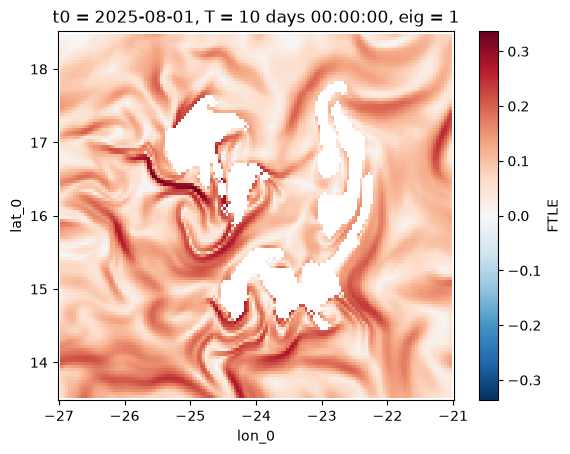

In [9]:
ftle.plot.pcolormesh(x="lon_0", y="lat_0")